In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
import psutil
from decimal import Decimal
import deepwave
import warnings
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
from pyramid_loss import PyramidLoss
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


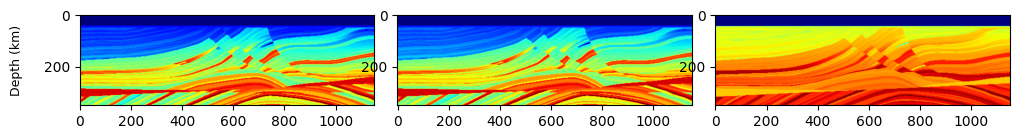

max values: tensor(4766.6040) tensor(2752.) tensor(2626.9998)
min values: tensor(1500.) tensor(800.) tensor(1009.)
model shape: torch.Size([352, 1150]) torch.Size([352, 1150]) torch.Size([352, 1150])


In [3]:
######### load data #########
dx = 10

vp_true = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy'))
vs_true = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy'))
rho_true = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy'))


submarine_deep = 43
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

17.387997
tensor(3927.0754, device='cuda:0') tensor(1847.8777, device='cuda:0')
tensor(1009., device='cuda:0') tensor(2409.4448, device='cuda:0')


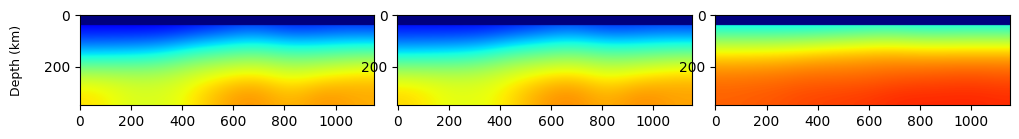

In [4]:
import scipy.ndimage
import scipy.io

sigma = 30

times = 6
if times != 0:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_n_times(vp_true, vs_true, rho_true, sigma, times, DEVICE)
else:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_once(vp_true, vs_true, rho_true, sigma, DEVICE)

snr_vp = ComputeSNR(vp_initial.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())

print(snr_vp)
print(vp_initial.max(),vp_initial.min())
vp_initial[:submarine_deep,:] = submarine_vp
vs_initial[:submarine_deep,:] = submarine_vs
rho_initial[:submarine_deep,:] = submarine_rho

print(rho_initial.min(),rho_initial.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_initial.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_initial.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()

In [5]:
loss_fn = 'l1'  # Options: 'l1', 'l2', 'laploss', 'W1', 'GSOT', 'WF', 'WECI', 'CS'
                # Determines the misfit function between synthetic and observed data

if times != 0:
    ##### save path
    vp_save_path = f'./rec/reconstruction_loss/EFWI_gau_en/init_2/vp/'
    vs_save_path = f'./rec/reconstruction_loss/EFWI_gau_en/init_2/vs/'
    rho_save_path = f'./rec/reconstruction_loss/EFWI_gau_en/init_2/rho/'
    main_path = f'./log_data/log_data_loss/EFWI_gau_en/init_2/'
else:
    vp_save_path = f'./rec/reconstruction_loss/EFWI_gau_en/init_1/vp/'
    vs_save_path = f'./rec/reconstruction_loss/EFWI_gau_en/init_1/vs/'
    rho_save_path = f'./rec/reconstruction_loss/EFWI_gau_en/init_1/rho/'
    main_path = f'./log_data/log_data_loss/EFWI_gau_en/init_1/'


if not os.path.exists(main_path):
    os.makedirs(main_path)

if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)
if not os.path.exists(vs_save_path):
    os.makedirs(vs_save_path)
if not os.path.exists(rho_save_path):
    os.makedirs(rho_save_path)
    


In [6]:
Physics = Physics_deepwave                              
                           
model_shape = [vp_true.shape[0], vp_true.shape[1]]                                 
                                                                                       
DT = 0.006                                               
F_PEAK = 8                                              
DH = dx                                                  

inpa = {                                
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500

In [7]:
### load obs and src, src_loc, rec_loc
obs_file_vx = './obs_data/d_obs_vx_src.npy'
obs_file_vy = './obs_data/d_obs_vy_src.npy'
d_obs_vx = torch.tensor(np.load(obs_file_vx))
d_obs_vy = torch.tensor(np.load(obs_file_vy))

src_loc = torch.tensor(np.load('./src_rec_positions/src_loc.npy'))
rec_loc = torch.tensor(np.load('./src_rec_positions/rec_loc.npy'))
src     = torch.tensor(np.load('./sources/src.npy'))

### sum source
num_super_sources = 10
sources_per_super = 10
source_distribution = 'random'# ('random' 或 'uniform')

#### 1.
result = encode_sources(obs_data_vx = d_obs_vx.squeeze(0),
                        obs_data_vy = d_obs_vy.squeeze(0),
                        source_locations = src_loc, 
                        receiver_locations  = rec_loc, 
                        source_functions = src,
                        num_super_sources = num_super_sources,
                        sources_per_super = sources_per_super,
                        source_distribution=source_distribution
                        )

#### 2
print(f"Encoded observation data shape (vx): {result['encoded_obs_data_vx'].shape}")
print(f"Encoded observation data shape (vy): {result['encoded_obs_data_vy'].shape}")
print(f"Encoded source location shape: {result['encoded_source_locations'].shape}")
print(f"Encoded receiver location shape: {result['encoded_receiver_locations'].shape}")
print(f"Encoded source function shape: {result['encoded_source_functions'].shape}")


d_obs_vx_encode = result['encoded_obs_data_vx'].unsqueeze(0).to(DEVICE)
d_obs_vy_encode = result['encoded_obs_data_vy'].unsqueeze(0).to(DEVICE)
src_loc_encode  = result['encoded_source_locations'].to(DEVICE)
rec_loc_encode  = result['encoded_receiver_locations'].to(DEVICE)
src_encode      = result['encoded_source_functions'].to(DEVICE)



Encoded observation data shape (vx): torch.Size([10, 2500, 1130])
Encoded observation data shape (vy): torch.Size([10, 2500, 1130])
Encoded source location shape: torch.Size([10, 10, 2])
Encoded receiver location shape: torch.Size([10, 1130, 2])
Encoded source function shape: torch.Size([10, 10, 2500])


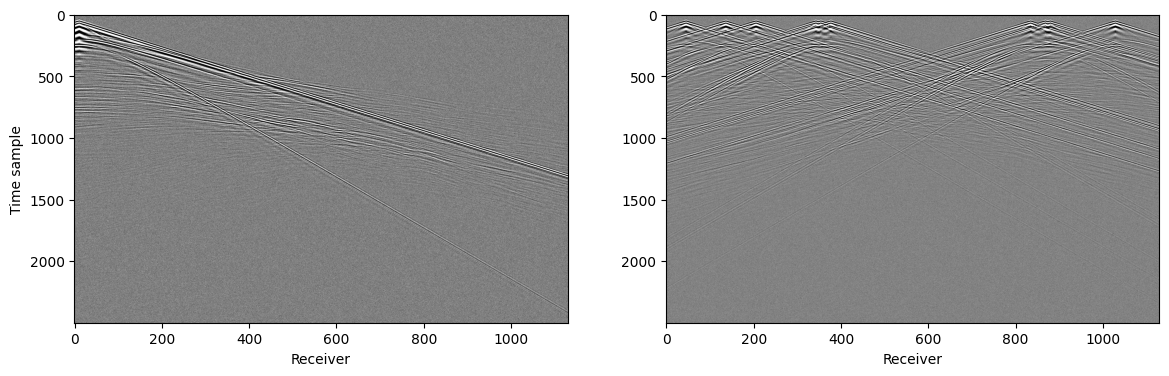

In [8]:

##### show these data
d_obs_vx_plot = d_obs_vx.squeeze(0)
d_obs_vx_en_plot = d_obs_vx_encode.squeeze(0)
vmin, vmax = torch.quantile(d_obs_vx_plot[1],
                            torch.tensor([0.01, 0.99]))
vsmin, vsmax = torch.quantile(d_obs_vx_en_plot[1],
                                 torch.tensor([0.01, 0.99]).to(DEVICE))


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(d_obs_vx_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Receiver")
ax[0].set_ylabel("Time sample")
ax[1].imshow(d_obs_vx_en_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vsmin, vmax=vsmax)
ax[1].set_xlabel("Receiver")
plt.subplots_adjust(hspace=0.6)  
plt.show()


In [9]:
vp_initial = vp_initial.to(DEVICE)
vs_initial = vs_initial.to(DEVICE)
rho_initial = rho_initial.to(DEVICE)
vp = vp_initial.requires_grad_(True)
vs = vs_initial.requires_grad_(True)
rho = rho_initial.requires_grad_(True)

criteria = torch.nn.L1Loss(reduction='sum')
criteria_model = torch.nn.L1Loss(reduction='sum')

optimer = torch.optim.Adam([{'params': [vp], 'lr': 6.0},
                            {'params': [vs], 'lr': 4.0},
                            {'params': [rho], 'lr': 2.0}])

In [10]:
all_loss_data = []
all_loss_vx_model = []
all_loss_vy_model = []
all_loss_rho_model = []
all_loss_model =[]
SNR_vp = []
SSIM_vp = []
Loss_vp = []
ERROR_vp = []
SNR_vs = []
SSIM_vs = []
Loss_vs = []
ERROR_vs = []
SNR_rho = []
SSIM_rho = []
Loss_rho = []
ERROR_rho = []
time_each_iter = []
def get_cpu_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2  
    
def get_gpu_memory():
    if torch.cuda.is_available():
        
        return torch.cuda.memory_allocated() / 1024 ** 2
    else:
        return 0
cpu_mem_log = [] 
gpu_mem_log = []

Iteration 5 = loss: 3.6900,model loss: 267281272.0000,time:6.92,snr_vp:18.231,snr_vs:18.258,snr_rho:22.640
Iteration 10 = loss: 3.4178,model loss: 264717388.0000,time:6.95,snr_vp:18.298,snr_vs:18.330,snr_rho:22.714
Iteration 15 = loss: 3.1612,model loss: 261540216.0000,time:6.95,snr_vp:18.374,snr_vs:18.385,snr_rho:22.793
Iteration 20 = loss: 2.9874,model loss: 258361248.0000,time:6.95,snr_vp:18.457,snr_vs:18.425,snr_rho:22.869


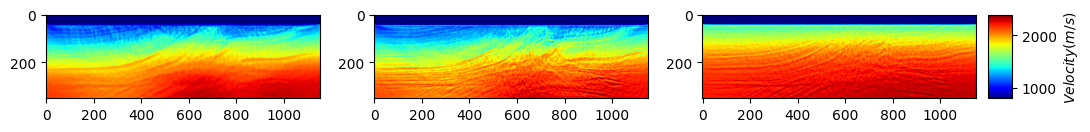

Iteration 25 = loss: 2.8953,model loss: 255028780.0000,time:6.93,snr_vp:18.543,snr_vs:18.462,snr_rho:22.922
Iteration 30 = loss: 2.8218,model loss: 251915688.0000,time:6.94,snr_vp:18.626,snr_vs:18.504,snr_rho:22.962
Iteration 35 = loss: 2.7614,model loss: 249350932.0000,time:6.94,snr_vp:18.702,snr_vs:18.550,snr_rho:22.992
Iteration 40 = loss: 2.7109,model loss: 247088836.0000,time:6.93,snr_vp:18.774,snr_vs:18.603,snr_rho:23.011


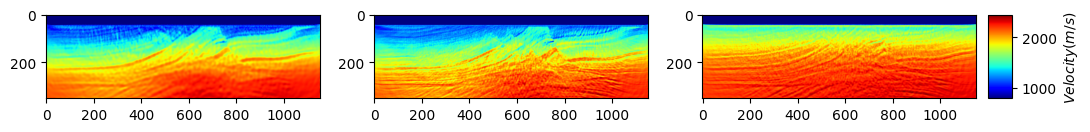

Iteration 45 = loss: 2.6677,model loss: 244996112.0000,time:6.93,snr_vp:18.842,snr_vs:18.662,snr_rho:23.022
Iteration 50 = loss: 2.6312,model loss: 243004572.0000,time:6.92,snr_vp:18.909,snr_vs:18.725,snr_rho:23.027
Iteration 55 = loss: 2.5998,model loss: 241056188.0000,time:6.92,snr_vp:18.975,snr_vs:18.792,snr_rho:23.028
Iteration 60 = loss: 2.5711,model loss: 239167760.0000,time:7.97,snr_vp:19.041,snr_vs:18.861,snr_rho:23.029


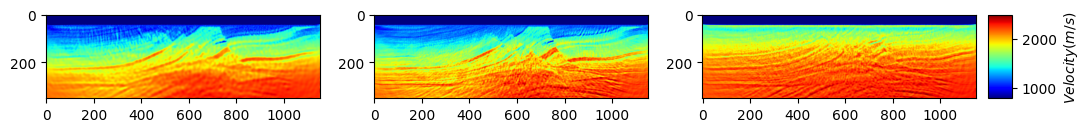

Iteration 65 = loss: 2.5432,model loss: 237242108.0000,time:7.96,snr_vp:19.107,snr_vs:18.933,snr_rho:23.031
Iteration 70 = loss: 2.5155,model loss: 235271336.0000,time:7.95,snr_vp:19.173,snr_vs:19.008,snr_rho:23.036
Iteration 75 = loss: 2.4860,model loss: 233202288.0000,time:7.96,snr_vp:19.241,snr_vs:19.089,snr_rho:23.045
Iteration 80 = loss: 2.4498,model loss: 231010444.0000,time:7.96,snr_vp:19.310,snr_vs:19.171,snr_rho:23.060


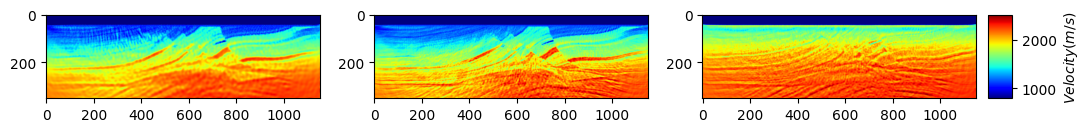

Iteration 85 = loss: 2.4020,model loss: 228683200.0000,time:7.96,snr_vp:19.380,snr_vs:19.252,snr_rho:23.085
Iteration 90 = loss: 2.3784,model loss: 226236288.0000,time:7.98,snr_vp:19.453,snr_vs:19.329,snr_rho:23.117
Iteration 95 = loss: 2.3596,model loss: 223817964.0000,time:7.96,snr_vp:19.524,snr_vs:19.402,snr_rho:23.148
Iteration 100 = loss: 2.3438,model loss: 221469912.0000,time:7.95,snr_vp:19.594,snr_vs:19.473,snr_rho:23.177


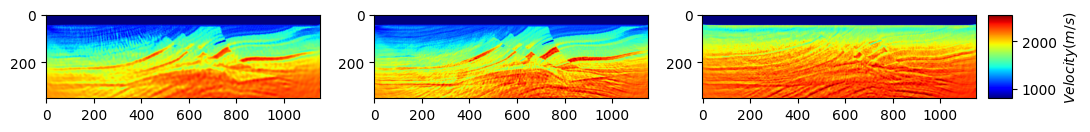

Iteration 105 = loss: 2.3293,model loss: 219221044.0000,time:7.96,snr_vp:19.661,snr_vs:19.543,snr_rho:23.205
Iteration 110 = loss: 2.3176,model loss: 217069340.0000,time:7.97,snr_vp:19.726,snr_vs:19.614,snr_rho:23.232
Iteration 115 = loss: 2.3048,model loss: 215003556.0000,time:7.95,snr_vp:19.790,snr_vs:19.685,snr_rho:23.260
Iteration 120 = loss: 2.2918,model loss: 213017904.0000,time:7.97,snr_vp:19.851,snr_vs:19.757,snr_rho:23.288


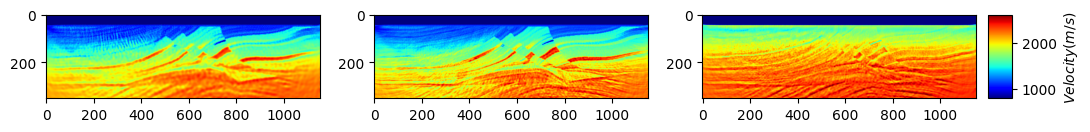

Iteration 125 = loss: 2.2831,model loss: 211104236.0000,time:7.95,snr_vp:19.911,snr_vs:19.829,snr_rho:23.317
Iteration 130 = loss: 2.2730,model loss: 209233840.0000,time:7.95,snr_vp:19.970,snr_vs:19.900,snr_rho:23.349
Iteration 135 = loss: 2.2600,model loss: 207402336.0000,time:7.96,snr_vp:20.027,snr_vs:19.969,snr_rho:23.381
Iteration 140 = loss: 2.2474,model loss: 205605424.0000,time:7.96,snr_vp:20.083,snr_vs:20.037,snr_rho:23.414


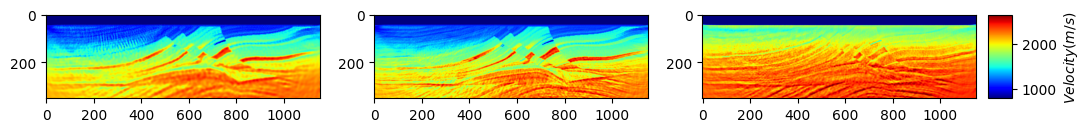

Iteration 145 = loss: 2.2372,model loss: 203838448.0000,time:7.95,snr_vp:20.138,snr_vs:20.102,snr_rho:23.447
Iteration 150 = loss: 2.2286,model loss: 202106048.0000,time:7.97,snr_vp:20.192,snr_vs:20.163,snr_rho:23.479
Iteration 155 = loss: 2.2231,model loss: 200408624.0000,time:7.96,snr_vp:20.245,snr_vs:20.220,snr_rho:23.511
Iteration 160 = loss: 2.2201,model loss: 198753032.0000,time:7.95,snr_vp:20.297,snr_vs:20.275,snr_rho:23.542


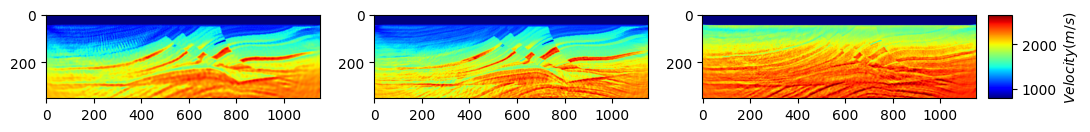

Iteration 165 = loss: 2.2165,model loss: 197140548.0000,time:7.96,snr_vp:20.349,snr_vs:20.328,snr_rho:23.573
Iteration 170 = loss: 2.2090,model loss: 195559572.0000,time:7.96,snr_vp:20.400,snr_vs:20.379,snr_rho:23.603
Iteration 175 = loss: 2.2014,model loss: 194010712.0000,time:7.96,snr_vp:20.450,snr_vs:20.429,snr_rho:23.633
Iteration 180 = loss: 2.1961,model loss: 192506524.0000,time:7.96,snr_vp:20.499,snr_vs:20.478,snr_rho:23.663


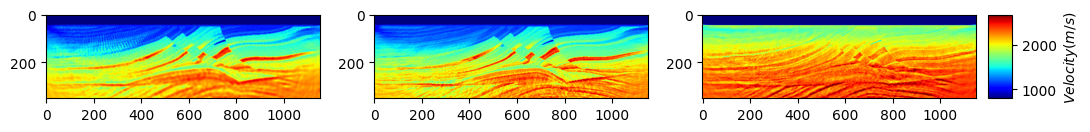

Iteration 185 = loss: 2.1933,model loss: 191056576.0000,time:7.95,snr_vp:20.548,snr_vs:20.525,snr_rho:23.692
Iteration 190 = loss: 2.1917,model loss: 189661432.0000,time:7.94,snr_vp:20.595,snr_vs:20.572,snr_rho:23.720
Iteration 195 = loss: 2.1888,model loss: 188325800.0000,time:7.96,snr_vp:20.640,snr_vs:20.620,snr_rho:23.749
Iteration 200 = loss: 2.1828,model loss: 187041676.0000,time:7.95,snr_vp:20.684,snr_vs:20.668,snr_rho:23.777


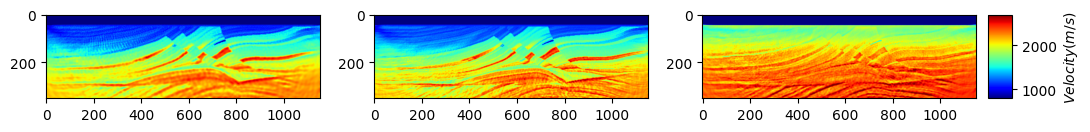

Iteration 205 = loss: 2.1755,model loss: 185802952.0000,time:7.95,snr_vp:20.727,snr_vs:20.718,snr_rho:23.805
Iteration 210 = loss: 2.1691,model loss: 184595344.0000,time:7.96,snr_vp:20.769,snr_vs:20.770,snr_rho:23.834
Iteration 215 = loss: 2.1635,model loss: 183402120.0000,time:7.96,snr_vp:20.810,snr_vs:20.824,snr_rho:23.864
Iteration 220 = loss: 2.1595,model loss: 182194100.0000,time:7.94,snr_vp:20.852,snr_vs:20.876,snr_rho:23.895


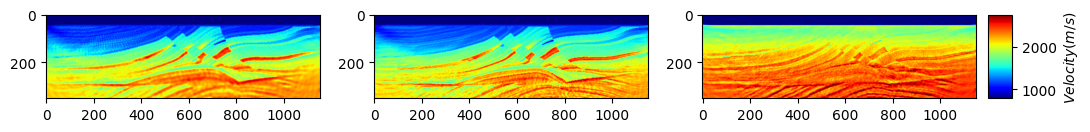

Iteration 225 = loss: 2.1566,model loss: 180967504.0000,time:7.96,snr_vp:20.896,snr_vs:20.927,snr_rho:23.926
Iteration 230 = loss: 2.1547,model loss: 179761272.0000,time:7.95,snr_vp:20.938,snr_vs:20.974,snr_rho:23.955
Iteration 235 = loss: 2.1548,model loss: 178609684.0000,time:7.95,snr_vp:20.980,snr_vs:21.017,snr_rho:23.984
Iteration 240 = loss: 2.1542,model loss: 177519760.0000,time:7.96,snr_vp:21.020,snr_vs:21.059,snr_rho:24.012


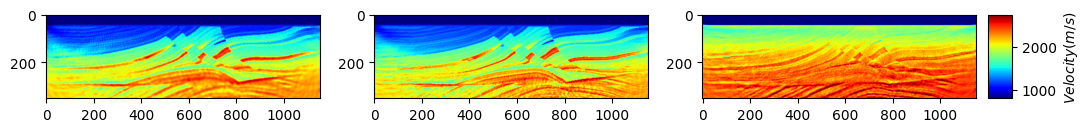

Iteration 245 = loss: 2.1497,model loss: 176488924.0000,time:7.95,snr_vp:21.058,snr_vs:21.099,snr_rho:24.039
Iteration 250 = loss: 2.1436,model loss: 175514244.0000,time:7.94,snr_vp:21.095,snr_vs:21.138,snr_rho:24.065
Iteration 255 = loss: 2.1419,model loss: 174586716.0000,time:7.95,snr_vp:21.131,snr_vs:21.175,snr_rho:24.090
Iteration 260 = loss: 2.1442,model loss: 173694652.0000,time:7.95,snr_vp:21.165,snr_vs:21.212,snr_rho:24.115


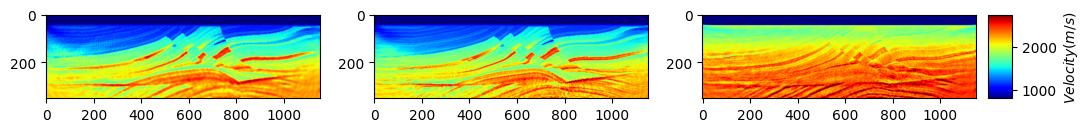

Iteration 265 = loss: 2.1461,model loss: 172834060.0000,time:7.96,snr_vp:21.199,snr_vs:21.248,snr_rho:24.139
Iteration 270 = loss: 2.1446,model loss: 172005624.0000,time:7.96,snr_vp:21.232,snr_vs:21.283,snr_rho:24.162
Iteration 275 = loss: 2.1390,model loss: 171202600.0000,time:7.97,snr_vp:21.264,snr_vs:21.317,snr_rho:24.185
Iteration 280 = loss: 2.1368,model loss: 170431012.0000,time:7.95,snr_vp:21.295,snr_vs:21.351,snr_rho:24.208


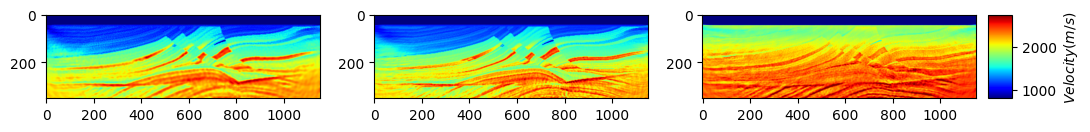

Iteration 285 = loss: 2.1360,model loss: 169684224.0000,time:7.96,snr_vp:21.325,snr_vs:21.384,snr_rho:24.230
Iteration 290 = loss: 2.1375,model loss: 168963908.0000,time:7.95,snr_vp:21.355,snr_vs:21.417,snr_rho:24.252
Iteration 295 = loss: 2.1387,model loss: 168266332.0000,time:7.94,snr_vp:21.384,snr_vs:21.449,snr_rho:24.274
Iteration 300 = loss: 2.1371,model loss: 167581984.0000,time:7.96,snr_vp:21.413,snr_vs:21.481,snr_rho:24.295


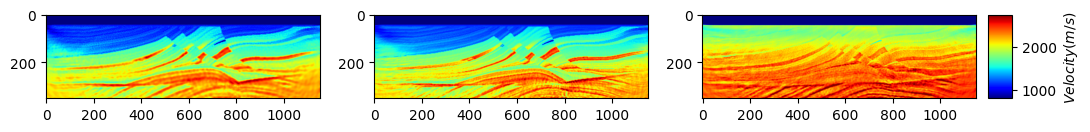

Running complete in 39m  34s


In [11]:
# Run optimisation/inversion

# freqs_bands1 = [
#     (0.1, 3),
#     (0.1, 5),
#     (0.1, 7.5),
#     (0.1, 10),
#     (0.1, 15),
#     (0.1, 20),
# ]

# import time
t_start = time.time()
mini_batches = 5
ITERATION = 300 


levels  = 6

for iter in range(ITERATION):
    loss_data_minibatch = []
    
    time_each_bath_start = time.time()
    for batch in range(mini_batches):
   
        optimer.zero_grad()
    
        src_loc_batch = src_loc_encode[batch::mini_batches].to(DEVICE)
        rec_loc_batch = rec_loc_encode[batch::mini_batches].to(DEVICE)
        src_batch = src_encode[batch::mini_batches].to(DEVICE) ## for true source
            
        physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'] ,size=NT,src=src_batch,
                    src_loc=src_loc_batch, rec_loc=rec_loc_batch
                    )
        with torch.no_grad():
            vp[:submarine_deep,:] = submarine_vp
            vs[:submarine_deep,:] = submarine_vs
            rho[:submarine_deep,:] = submarine_rho
            vp[vp>vp_true.max()] = vp_true.max()
            vp[vp<vp_true.min()] = vp_true.min()
    
            vs[vs>vs_true.max()] = vs_true.max()
            vs[vs<vs_true.min()] = vs_true.min()
    
            rho[rho>rho_true.max()] = rho_true.max()
            rho[rho<rho_true.min()] = rho_true.min()
           
            vp = vp.requires_grad_(True)
            vs = vs.requires_grad_(True)
            rho = rho.requires_grad_(True)          
    
        vp = vp.to(DEVICE)
        vs = vs.to(DEVICE)
        rho = rho.to(DEVICE)
        

        taux_est = physics(vp,vs,rho) 
        taux_vx_est_filtered = taux_est[0].to(DEVICE)
        taux_vy_est_filtered = taux_est[1].to(DEVICE)
        
        taux_est_all = torch.cat((taux_vx_est_filtered,taux_vy_est_filtered),dim=1).to(DEVICE)
        
        d_obs_vx_filtered = d_obs_vx_encode[:, batch::mini_batches].to(DEVICE)
        d_obs_vy_filtered = d_obs_vy_encode[:, batch::mini_batches].to(DEVICE)
        
        d_obs_filtered_all = torch.cat((d_obs_vx_filtered,d_obs_vy_filtered),dim=1).to(DEVICE)


        kernel_size = 5
        channels = taux_est_all.shape[1]
        sigma = 3
        dtype = torch.float
        

        criteria = PyramidLoss(pyramid='gaussian', loss='l1',reduction = 'mean', levels=levels, channels=channels, 
                       kernel_size=kernel_size, sigma=sigma,
                       use_weights = True, # weight = 2^l
                       #weights = [1, 2, 4, 8, 16, 32, 64],
                       device=DEVICE)
        loss_data = 1.0e8*criteria(taux_est_all, d_obs_filtered_all)

        
        loss = loss_data
    
        loss.backward()
    
        optimer.step()

    all_loss_data.append(loss_data.detach().cpu().item())
    time_each_bath_end = time.time()
    time_each_iter.append(time_each_bath_end - time_each_bath_start)
    
    mem_now_cpu = get_cpu_memory()
    cpu_mem_log.append(mem_now_cpu)
    mem_now_gpu = get_gpu_memory()
    gpu_mem_log.append(mem_now_gpu)
    
    with torch.no_grad():
        all_loss_vx_model.append(
            criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()
        )
    
        all_loss_vy_model.append(
            criteria_model(vs.cpu(),vs_true.cpu()).detach().numpy().item()
            )
        all_loss_rho_model.append(
            criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
        )
        all_loss_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )


    snr_vp = ComputeSNR(vp.detach().cpu().numpy(), \
              vp_true.detach().cpu().numpy())
    SNR_vp = np.append(SNR_vp, snr_vp)
    snr_vs = ComputeSNR(vs.detach().cpu().numpy(), \
              vs_true.detach().cpu().numpy())
    SNR_vs = np.append(SNR_vs, snr_vs)
    snr_rho = ComputeSNR(rho.detach().cpu().numpy(), \
              rho_true.detach().cpu().numpy())
    SNR_rho = np.append(SNR_rho, snr_rho)


    if (iter+1)%5 == 0:
        print(f"Iteration {iter + 1} = loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.4f},time:{time_each_iter[-1]:.2f},snr_vp:{SNR_vp[-1]:.3f},snr_vs:{SNR_vs[-1]:.3f},snr_rho:{SNR_rho[-1]:.3f}")
    if (iter+1)%10==0:
        np.save(vp_save_path + 'recx_iter_%s.npy' % (iter + 1), vp.cpu().detach().numpy())
        np.save(vs_save_path + 'recx_iter_%s.npy' % (iter + 1), vs.cpu().detach().numpy())
        np.save(rho_save_path + 'recx_iter_%s.npy' % (iter + 1), rho.cpu().detach().numpy())
    if (iter+1)%20 == 0:
    
        fig, ax = plt.subplots(1,3,figsize=(12, 6))
        im0 = ax[0].imshow(vp.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im1 = ax[1].imshow(vs.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im2 = ax[2].imshow(rho.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        points = ax[1].get_position().get_points()
        dy = points[1, 1] - points[0, 1]
        cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
        cax.yaxis.set_ticks_position("right")
        cbar = fig.colorbar(im1, cax=cax, orientation="vertical", 
                        extend="neither", label="$Velocity (m/s)$"
                        )
        plt.show()
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [12]:
#print(all_loss_data)
### path for log data

with torch.no_grad():
    
    np.savetxt(main_path+'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path+'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vp_model.txt', all_loss_vx_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vs_model.txt', all_loss_vy_model, delimiter=',')
    np.savetxt(main_path+'all_loss_rho_model.txt', all_loss_rho_model, delimiter=',')
    
    np.savetxt(main_path+'vp_snr.txt', SNR_vp,delimiter=',')
    np.savetxt(main_path+'vs_snr.txt', SNR_vs,delimiter=',')
    np.savetxt(main_path+'rho_snr.txt', SNR_rho,delimiter=',')
    
    
    np.savetxt(main_path+'time.txt',time_each_iter , delimiter=',')
    
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')


In [13]:
#print(all_loss_data)